In [25]:
import os
import tensorflow as tf

try:
    from google.colab import drive
    _HAS_COLAB = True
except ImportError:
    drive = None
    _HAS_COLAB = False

# 1. Conectar a Google Drive solo si estamos en Colab y el servicio existe
if _HAS_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass

# 2. Ruta configurable del dataset
DATASET_ROOT = os.getenv('DATASET_ROOT', '/home/desarrolloab/Documentos/ML/maize_dataset')
DATA_DIR = os.path.join(DATASET_ROOT, 'clean')

# 3. Verificación de las carpetas
if os.path.exists(DATA_DIR):
    clases = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f"Ruta encontrada: {DATA_DIR}")
    print(f"Clases detectadas listas para entrenar: {clases}")
else:
    print(f"Error: No se encontró la ruta {DATA_DIR}. Verifica que el nombre sea exacto.")

Ruta encontrada: /home/desarrolloab/Documentos/ML/maize_dataset/clean
Clases detectadas listas para entrenar: ['fall_armyworm', 'potassium_deficiency', 'phosphorus_deficiency', 'healthy', 'common_rust', 'northern_corn_leaf_blight', 'gray_leaf_spot', 'aphids_pest', 'nitrogen_deficiency']


In [26]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, applications

# Verificar que Colab te asignó una GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" ¡Excelente! GPU detectada: {gpus}")
else:
    print("ADVERTENCIA: No se detectó GPU. Ve a 'Entorno de ejecución' -> 'Cambiar tipo de entorno de ejecución' y selecciona 'T4 GPU'.")

ADVERTENCIA: No se detectó GPU. Ve a 'Entorno de ejecución' -> 'Cambiar tipo de entorno de ejecución' y selecciona 'T4 GPU'.


In [27]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
BASE_DIR = os.path.join(DATASET_ROOT, 'clean')

print("Cargando y dividiendo el dataset automáticamente...")

train_dataset_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_dataset_raw.class_names

val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_batches = tf.data.experimental.cardinality(val_test_dataset)
val_dataset = val_test_dataset.take(val_batches // 2)
test_dataset = val_test_dataset.skip(val_batches // 2)

# ¡AQUÍ ESTÁ LA MAGIA SALVA-RAM!
# Quitamos el .cache() y bajamos el shuffle a 300
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset_raw.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print(f"\n✅ Conjuntos de datos listos. Clases detectadas ({len(class_names)}): {class_names}")

Cargando y dividiendo el dataset automáticamente...
Found 25284 files belonging to 9 classes.
Using 20228 files for training.
Found 25284 files belonging to 9 classes.
Using 5056 files for validation.

✅ Conjuntos de datos listos. Clases detectadas (9): ['aphids_pest', 'common_rust', 'fall_armyworm', 'gray_leaf_spot', 'healthy', 'nitrogen_deficiency', 'northern_corn_leaf_blight', 'phosphorus_deficiency', 'potassium_deficiency']


In [28]:
print(f"Clases a balancear: {class_names}")
print("Calculando desbalance de forma optimizada en memoria...")

# Truco: Extraemos solo las etiquetas (y) sin procesar los tensores de imágenes (x)
y_train_indices = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_dataset_raw], axis=0)

# Calculamos los pesos
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights_dict = dict(enumerate(pesos))

print("\nPesos de compensación generados:")
for idx, clase in enumerate(class_names):
    print(f" - {clase}: {class_weights_dict[idx]:.4f}")

Clases a balancear: ['aphids_pest', 'common_rust', 'fall_armyworm', 'gray_leaf_spot', 'healthy', 'nitrogen_deficiency', 'northern_corn_leaf_blight', 'phosphorus_deficiency', 'potassium_deficiency']
Calculando desbalance de forma optimizada en memoria...

Pesos de compensación generados:
 - aphids_pest: 38.7510
 - common_rust: 1.2175
 - fall_armyworm: 0.5799
 - gray_leaf_spot: 2.5140
 - healthy: 0.3199
 - nitrogen_deficiency: 5.5771
 - northern_corn_leaf_blight: 0.4146
 - phosphorus_deficiency: 4.5497
 - potassium_deficiency: 10.6519


In [29]:
# Capas de Data Augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.1),
], name="data_augmentation_layer")

# Cargar preentrenado (MobileNetV3Small para dispositivos móviles)
base_model = applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base_model.trainable = False # Congelamos el conocimiento base

# Ensamblamos la red final
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

# ¡AQUÍ ESTÁ LA MAGIA! El número de neuronas se adapta automáticamente a las carpetas encontradas
num_clases = len(class_names)
outputs = layers.Dense(num_clases, activation='softmax', name='prediccion_enfermedad')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Usa 0.0001 en lugar del valor por defecto
    loss='categorical_crossentropy', # Asegúrate de que coincida con tus etiquetas (o sparse_categorical_crossentropy si son enteros)
    metrics=['accuracy']
)

print(f" Arquitectura construida para {num_clases} clases. Resumen del modelo:")
model.summary()

 Arquitectura construida para 9 clases. Resumen del modelo:


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediccion_enfermedad (Dense)   │ (None, 9)              │         5,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,313 (3.60 MB)

 Trainable params: 5,193 (20.29 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [30]:
# Descongelamos el modelo base
base_model.trainable = True

# Volvemos a congelar casi todo, excepto las últimas 20 capas
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Volvemos a compilar pero con un Learning Rate MUY BAJO
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# Entrenamos otras 10 épocas de ajuste fino
history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10


I0000 00:00:1781885691.994273  132126 shuffle_dataset_op.cc:453] ShuffleDatasetV3:1040: Filling up shuffle buffer (this may take a while): 413 of 1000
I0000 00:00:1781885696.231546  132126 shuffle_dataset_op.cc:483] Shuffle buffer filled.


633/633 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.1010 - loss: 2.4803 - precision: 0.0787 - recall: 0.0053 - val_accuracy: 0.1547 - val_loss: 2.1737 - val_precision: 0.1875 - val_recall: 0.0012
Epoch 2/10


I0000 00:00:1781885788.614674  133240 shuffle_dataset_op.cc:453] ShuffleDatasetV3:1040: Filling up shuffle buffer (this may take a while): 277 of 1000
I0000 00:00:1781885798.659258  133240 shuffle_dataset_op.cc:453] ShuffleDatasetV3:1040: Filling up shuffle buffer (this may take a while): 527 of 1000
I0000 00:00:1781885802.415652  133240 shuffle_dataset_op.cc:483] Shuffle buffer filled.
W0000 00:00:1781885802.424346  132122 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19268992 bytes after encountering the first element of size 19268992 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


633/633 ━━━━━━━━━━━━━━━━━━━━ 121s 153ms/step - accuracy: 0.2030 - loss: 2.0585 - precision: 0.2889 - recall: 0.0129 - val_accuracy: 0.3473 - val_loss: 1.8315 - val_precision: 0.8222 - val_recall: 0.0146
Epoch 3/10


...

633/633 ━━━━━━━━━━━━━━━━━━━━ 108s 149ms/step - accuracy: 0.6558 - loss: 0.9956 - precision: 0.8315 - recall: 0.3916 - val_accuracy: 0.7401 - val_loss: 0.8909 - val_precision: 0.8847 - val_recall: 0.4917
Epoch 10/10


I0000 00:00:1781886686.809482  145360 shuffle_dataset_op.cc:453] ShuffleDatasetV3:1040: Filling up shuffle buffer (this may take a while): 279 of 1000


  1/633 ━━━━━━━━━━━━━━━━━━━━ 3:59:56 23s/step - accuracy: 0.5625 - loss: 0.8893 - precision: 0.5000 - recall: 0.2812

I0000 00:00:1781886699.313633  145360 shuffle_dataset_op.cc:483] Shuffle buffer filled.
W0000 00:00:1781886699.313753  145359 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19268736 bytes after encountering the first element of size 19268736 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1781886699.314107  132122 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19268992 bytes after encountering the first element of size 19268992 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


633/633 ━━━━━━━━━━━━━━━━━━━━ 113s 144ms/step - accuracy: 0.6783 - loss: 0.9260 - precision: 0.8385 - recall: 0.4394 - val_accuracy: 0.7551 - val_loss: 0.8435 - val_precision: 0.8820 - val_recall: 0.5293


In [31]:
import os

EPOCHS = 20

# 1. Crear una carpeta local en tu proyecto llamada 'modelos_locales'
os.makedirs('modelos_locales', exist_ok=True)
MODEL_SAVE_PATH = 'modelos_locales/mobilenetv3_maiz_mejor_modelo.keras'

# 2. Configurar el callback para guardar localmente
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

print("\n ¡Iniciando el entrenamiento en la GPU!")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb] # <-- Le pasamos el callback corregido
)

print(f"\n Entrenamiento finalizado. El mejor modelo se guardó en: {MODEL_SAVE_PATH}")


 ¡Iniciando el entrenamiento en la GPU!
Epoch 1/20


I0000 00:00:1781886800.448342  147386 shuffle_dataset_op.cc:453] ShuffleDatasetV3:1040: Filling up shuffle buffer (this may take a while): 285 of 1000
I0000 00:00:1781886810.491439  147386 shuffle_dataset_op.cc:453] ShuffleDatasetV3:1040: Filling up shuffle buffer (this may take a while): 568 of 1000


  1/633 ━━━━━━━━━━━━━━━━━━━━ 3:57:21 23s/step - accuracy: 0.8125 - loss: 0.4559 - precision: 0.9500 - recall: 0.5938

I0000 00:00:1781886812.720736  147386 shuffle_dataset_op.cc:483] Shuffle buffer filled.
W0000 00:00:1781886812.721230  132122 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19268992 bytes after encountering the first element of size 19268992 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6874 - loss: 0.9084 - precision: 0.8458 - recall: 0.4678
Epoch 1: val_loss improved from None to 0.79075, saving model to modelos_locales/mobilenetv3_maiz_mejor_modelo.keras

Epoch 1: finished saving model to modelos_locales/mobilenetv3_maiz_mejor_modelo.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 113s 143ms/step - accuracy: 0.6896 - loss: 0.8905 - precision: 0.8438 - recall: 0.4725 - val_accuracy: 0.7749 - val_loss: 0.7907 - val_precision: 0.8834 - val_recall: 0.5696
Epoch 2/20


...

633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8212 - loss: 0.4966 - precision: 0.8809 - recall: 0.7578
Epoch 19: val_loss improved from 0.43070 to 0.42464, saving model to modelos_locales/mobilenetv3_maiz_mejor_modelo.keras

Epoch 19: finished saving model to modelos_locales/mobilenetv3_maiz_mejor_modelo.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 119s 151ms/step - accuracy: 0.8224 - loss: 0.5092 - precision: 0.8824 - recall: 0.7570 - val_accuracy: 0.8596 - val_loss: 0.4246 - val_precision: 0.9115 - val_recall: 0.8109
Epoch 20/20


I0000 00:00:1781888975.515564  186716 shuffle_dataset_op.cc:453] ShuffleDatasetV3:1040: Filling up shuffle buffer (this may take a while): 278 of 1000


  1/633 ━━━━━━━━━━━━━━━━━━━━ 4:03:06 23s/step - accuracy: 0.8438 - loss: 0.2560 - precision: 0.8621 - recall: 0.7812

I0000 00:00:1781888988.371161  186716 shuffle_dataset_op.cc:483] Shuffle buffer filled.


633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8232 - loss: 0.5304 - precision: 0.8798 - recall: 0.7578
Epoch 20: val_loss improved from 0.42464 to 0.41987, saving model to modelos_locales/mobilenetv3_maiz_mejor_modelo.keras

Epoch 20: finished saving model to modelos_locales/mobilenetv3_maiz_mejor_modelo.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 119s 151ms/step - accuracy: 0.8224 - loss: 0.5132 - precision: 0.8804 - recall: 0.7579 - val_accuracy: 0.8643 - val_loss: 0.4199 - val_precision: 0.9103 - val_recall: 0.8153

 Entrenamiento finalizado. El mejor modelo se guardó en: modelos_locales/mobilenetv3_maiz_mejor_modelo.keras


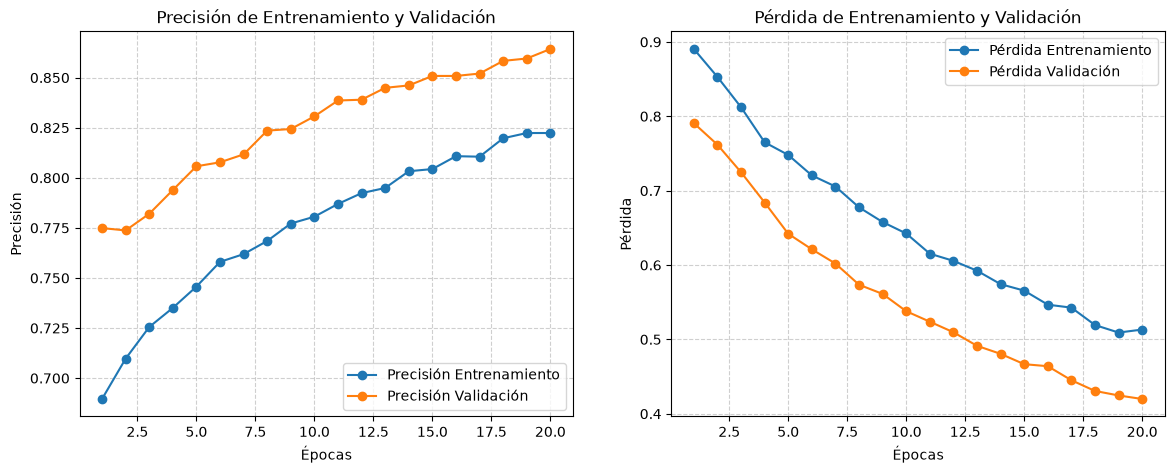

In [32]:
import matplotlib.pyplot as plt

# Extraer datos del historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento', marker='o')
plt.plot(epochs_range, val_acc, label='Precisión Validación', marker='o')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento', marker='o')
plt.plot(epochs_range, val_loss, label='Pérdida Validación', marker='o')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Evaluando el modelo con el conjunto de prueba (Test Dataset)...
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.8430 - loss: 0.4487 - precision: 0.8852 - recall: 0.7994

Resultados Finales en Test -> Precisión: 84.30% | Pérdida: 0.4487
Generando predicciones detalladas...

REPORTE DE CLASIFICACIÓN FINAL
                           precision    recall  f1-score   support

              aphids_pest       0.69      1.00      0.81        11
              common_rust       1.00      0.98      0.99       220
            fall_armyworm       0.92      0.80      0.85       479
           gray_leaf_spot       0.53      0.92      0.67       120
                  healthy       0.87      0.92      0.90       846
      nitrogen_deficiency       0.79      0.60      0.68        52
northern_corn_leaf_blight       0.92      0.76      0.83       717
    phosphorus_deficiency       0.54      0.89      0.68        57
     potassium_deficiency       0.27      0.50      0.35        26

               

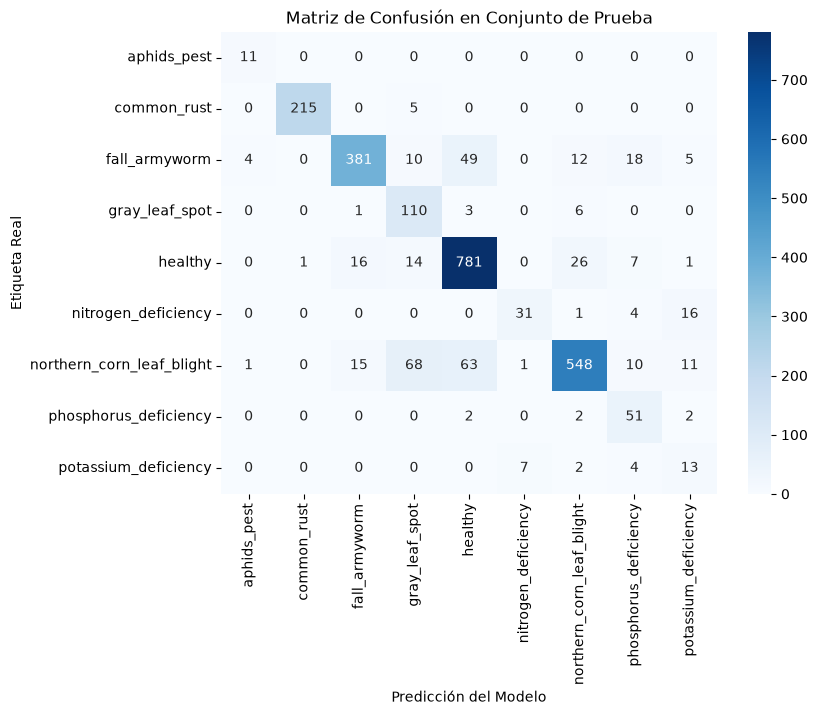

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Evaluando el modelo con el conjunto de prueba (Test Dataset)...")
# 1. Obtener las métricas generales
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_dataset)
print(f"\nResultados Finales en Test -> Precisión: {test_acc*100:.2f}% | Pérdida: {test_loss:.4f}")

# 2. Extraer predicciones y etiquetas reales para la Matriz
y_true = []
y_pred = []

print("Generando predicciones detalladas...")
for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# 3. Imprimir el Reporte de Clasificación (Aquí verás el Macro F1-Score)
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Dibujar la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión en Conjunto de Prueba')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

In [34]:
import os
import tensorflow as tf

print("Iniciando conversión a TensorFlow Lite...")

# 1. Cargar el convertidor con tu modelo entrenado
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 2. Aplicar optimización dinámica (Cuantización)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Realizar la conversión
tflite_model = converter.convert()

# --- CAMBIO PARA LOCAL: Crear carpeta local si no existe ---
os.makedirs('modelo_tflite', exist_ok=True)

# 4. Guardar el modelo .tflite localmente
tflite_path = 'modelo_tflite/doctor_maiz_optimizado.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# 5. Guardar el archivo .txt con los nombres de las clases en orden
labels_path = 'modelo_tflite/etiquetas_maiz.txt'
with open(labels_path, 'w') as f:
    f.write('\n'.join(class_names))

print(f"\n ¡Éxito! Modelo TFLite comprimido guardado localmente en: {tflite_path}")
print(f" Etiquetas guardadas en: {labels_path}")

Iniciando conversión a TensorFlow Lite...
INFO:tensorflow:Assets written to: /tmp/tmpagj2gjfe/assets


INFO:tensorflow:Assets written to: /tmp/tmpagj2gjfe/assets


Saved artifact at '/tmp/tmpagj2gjfe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_733')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  128385700387856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128391358462864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128391703257232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128391358448080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128385700386320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128391703259152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128391358462288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128391703261648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128385703834256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128391703264720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1283857003

W0000 00:00:1781889121.686859   46371 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781889121.687039   46371 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781889121.687327   46371 reader.cc:83] Reading SavedModel from: /tmp/tmpagj2gjfe
I0000 00:00:1781889121.692957   46371 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781889121.692966   46371 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpagj2gjfe
I0000 00:00:1781889121.757574   46371 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781889122.135699   46371 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpagj2gjfe
I0000 00:00:1781889122.225559   46371 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 538242 microseconds.
